# RSA depth: RDM geometry, MDS, and time-resolved distance to DMFC

**What RSA is, in one paragraph:** Representational Similarity Analysis compares two
systems (here, a trained RNN and real DMFC neurons) not by matching their units
one-to-one — that is impossible, an RNN has 160 artificial units and DMFC has 54 real
neurons — but by comparing the *pattern of dissimilarities between conditions* each
system produces. If short/480ms/eye and short/560ms/eye look almost identical to the
RNN, and they also look almost identical in DMFC, that's evidence the two systems
represent those two conditions the same way, regardless of what their individual units
are doing. That condition-by-condition dissimilarity structure is called a
**representational dissimilarity matrix (RDM)**.

**What this notebook adds beyond `results_summary.ipynb`:** that notebook reports one
number per seed — the distance between the model's RDM and DMFC's RDM, collapsed
across the whole trial. This notebook shows the RDMs themselves (so you can see *what*
is similar or different, not just *how much*), a 2D visualization of that geometry
(MDS), and how the model-to-DMFC distance changes moment-to-moment across the trial
(time-resolved RSA) instead of being collapsed into one number.

**Data covered, same as `results_summary.ipynb`:**

| arm | seeds |
|---|---|
| `bptt` | 10/10 |
| `rflo` | 10/10 |
| `pc_steps20` | 1, 5, 7, 9 (activation-store collision lost the rest — see that notebook) |
| `pc_steps100` | all but seed 1 (incomplete run) |

No seed is excluded on behavioral grounds (AGENTS.md invariant) — PC's already-
diagnosed collapsed seeds are in this geometry exactly like every other seed.

This notebook only *reads* saved artifacts from `scripts/run_rsa_geometry.py` and
`scripts/plot_rsa_temporal_summary.py` (plus the noise ceiling already computed by
`scripts/run_rsa.py`) — it never retrains or re-extracts anything.

**A caveat that shows up below:** `build_rdm`'s dissimilarity is `1 - Pearson
correlation` between two conditions' activity patterns. That is undefined when a
condition's pattern has ~zero variance, which happens at the very first (pre-stimulus
baseline) time bin, before Ready has even occurred — you'll see a gap in the
time-resolved curve at time 0 because of this. It's a property of the metric, not a
bug.

In [1]:
import json
from pathlib import Path
import numpy as np
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
RSA_DIR = REPO_ROOT / "results" / "rsa"

## How to read an RDM heatmap

Every RDM below is a 20x20 grid: one row and one column per canonical condition
(prior x sample interval `ts` x effector), always in this fixed order —

`short/480/eye, 560/eye, 640/eye, 720/eye, 800/eye, 480/hand, ..., 800/hand,`
`long/800/eye, 900/eye, 1000/eye, 1100/eye, 1200/eye, 800/hand, ..., 1200/hand`

so rows/columns 0-9 are the **short** prior (0-4 eye, 5-9 hand) and 10-19 are the
**long** prior (10-14 eye, 15-19 hand). A cell's color is the dissimilarity between
that pair of conditions: dark/low = the two conditions look nearly identical to this
system, bright/high = very different. The diagonal is always exactly 0 (a condition
compared to itself).

**What to look for:** DMFC's own RDM (shown first, below) has a visible 2x2 block
structure — the short-prior block, the long-prior block, and a sharper split between
eye and hand within each. That block structure is a real, physical fact about how
DMFC represents this task. A model arm's RDM is "good" to the extent its own block
structure resembles DMFC's — same rough blocks, similar within-block gradients from
`ts` tuning. A model whose RDM looks nearly uniform (little contrast anywhere) is one
whose activity barely distinguishes conditions at all.

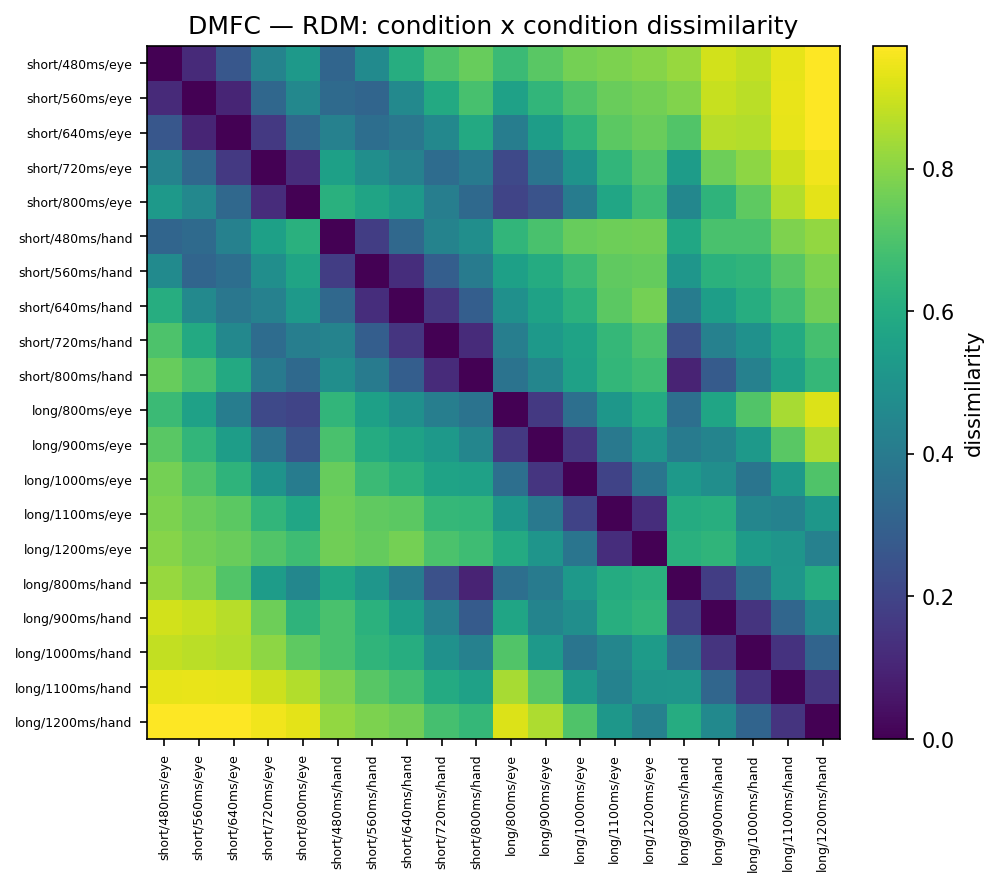

In [2]:
display(Image(filename=REPO_ROOT / "results" / "figures" / "dmfc" / "dmfc_rdm_heatmap.png"))

## RDM gallery: every seed's condition geometry, per arm

DMFC's RDM (top row, repeated for reference) next to **every seed** for that arm — not
one "representative" seed, so the seed-to-seed spread in the geometry itself stays
visible (AGENTS.md: seeds are the unit of evidence). All panels within a gallery share
one color scale. Each seed's own single-panel RDM (identical to one panel here, full
size) also lives at `results/figures/<arm>/seed_XXXX/<rule>_rdm_heatmap.png` if you
want to inspect one seed on its own outside this notebook.

### BPTT (10/10 seeds)

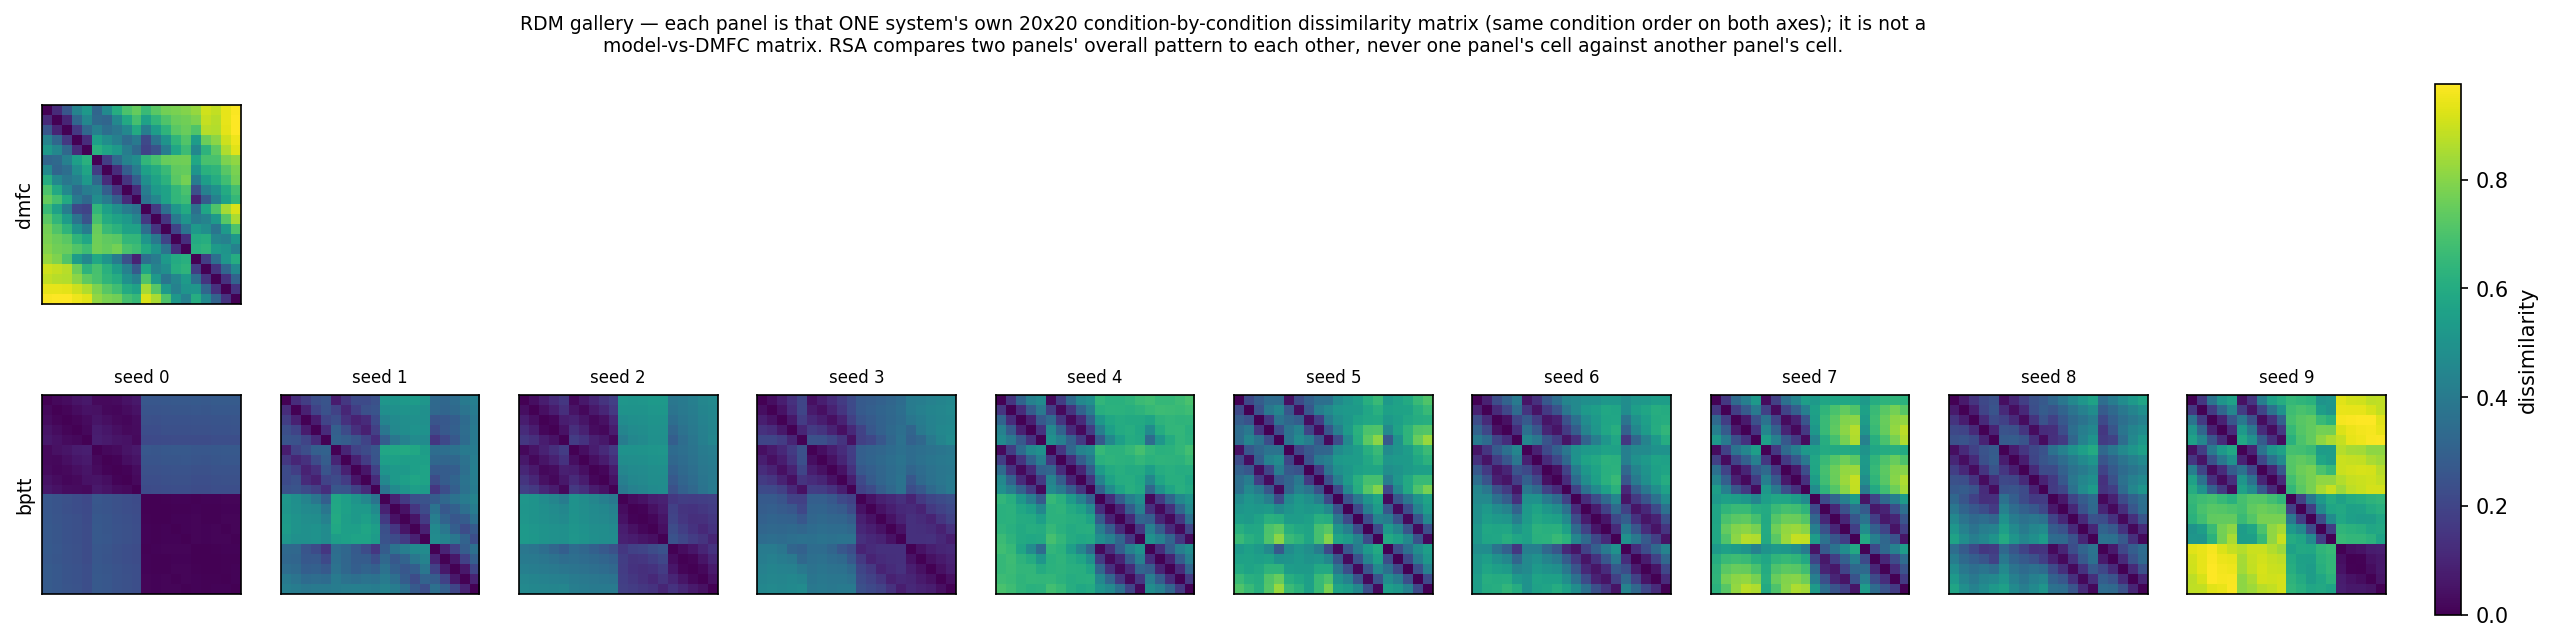

In [3]:
display(Image(filename=RSA_DIR / "bptt_vs_dmfc" / "figures" / "rdm_gallery_bptt.png"))

### RFLO (10/10 seeds)

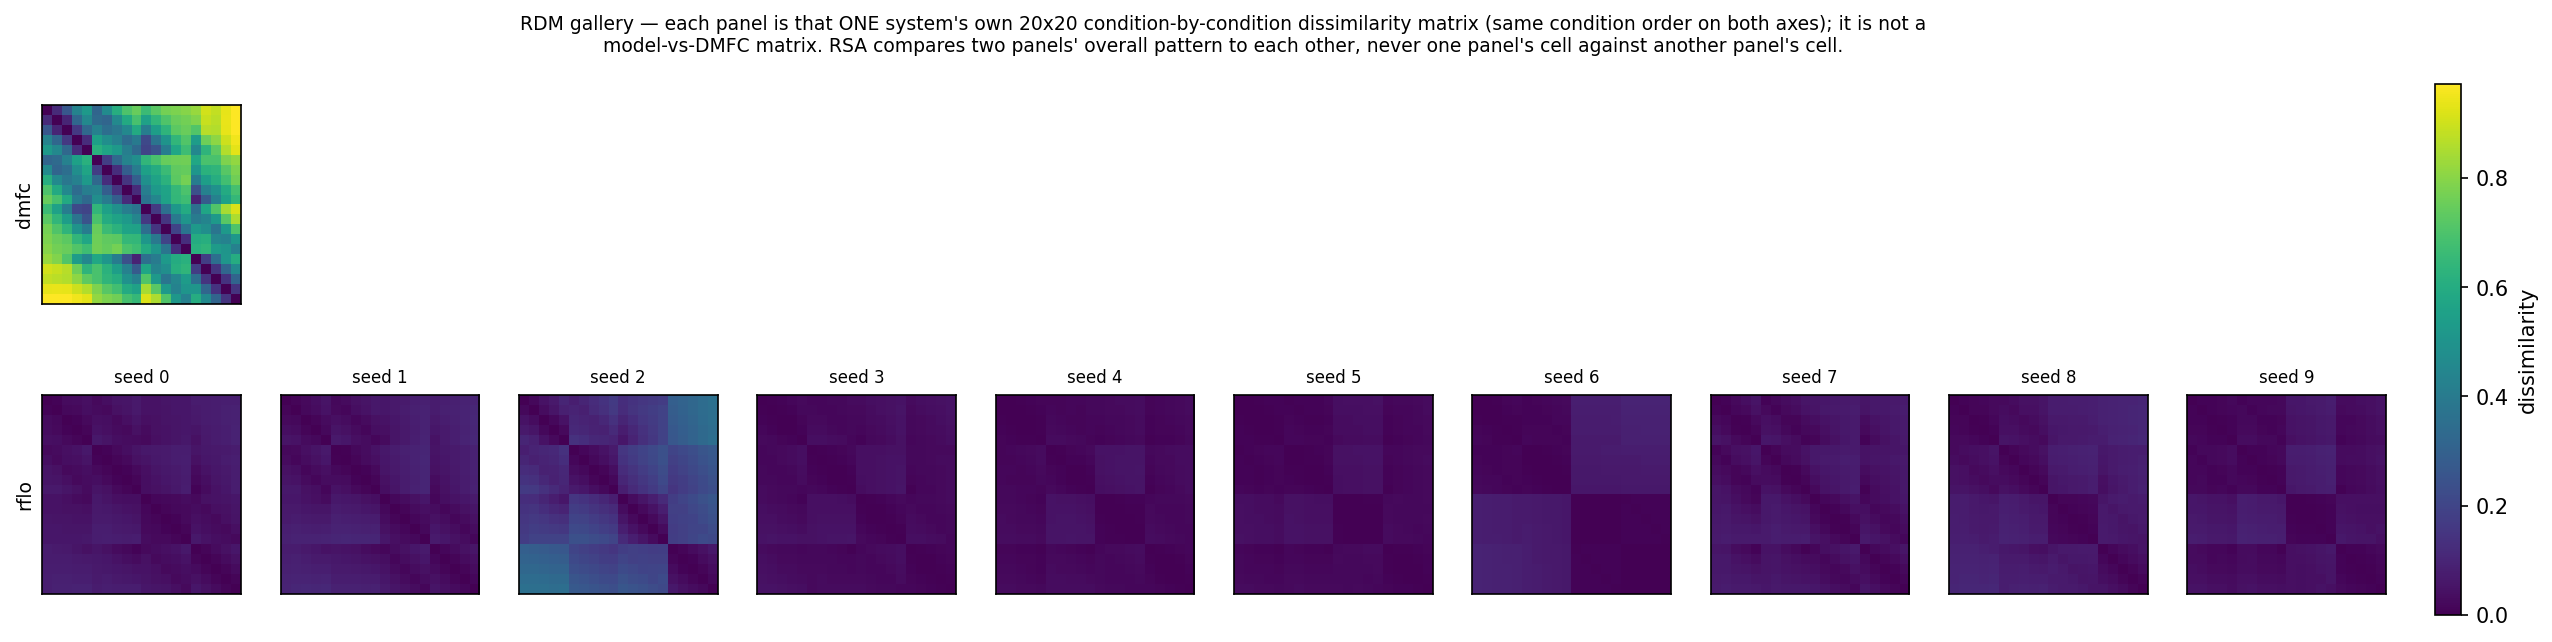

In [4]:
display(Image(filename=RSA_DIR / "rflo_vs_dmfc" / "figures" / "rdm_gallery_rflo.png"))

### PC, pc_inference_steps=20 (seeds 1,5,7,9 only)

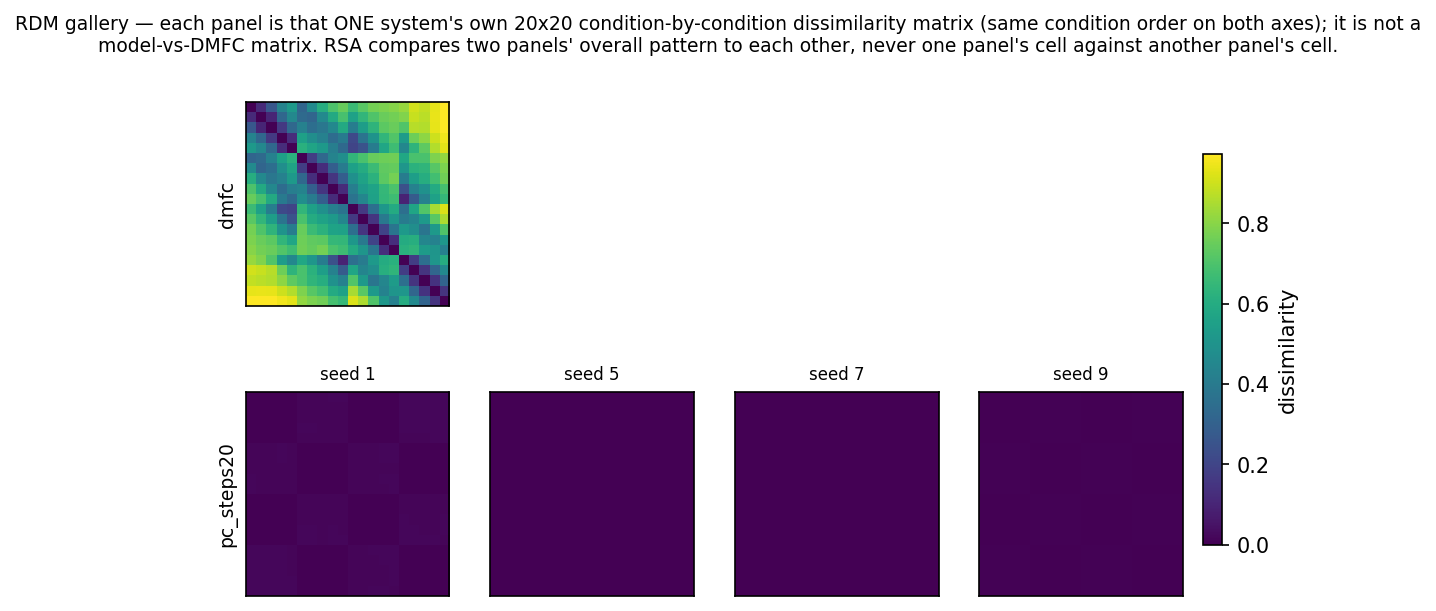

In [5]:
display(Image(filename=RSA_DIR / "pc_steps20_vs_dmfc" / "figures" / "rdm_gallery_pc.png"))

### PC, pc_inference_steps=100 (all but seed 1)

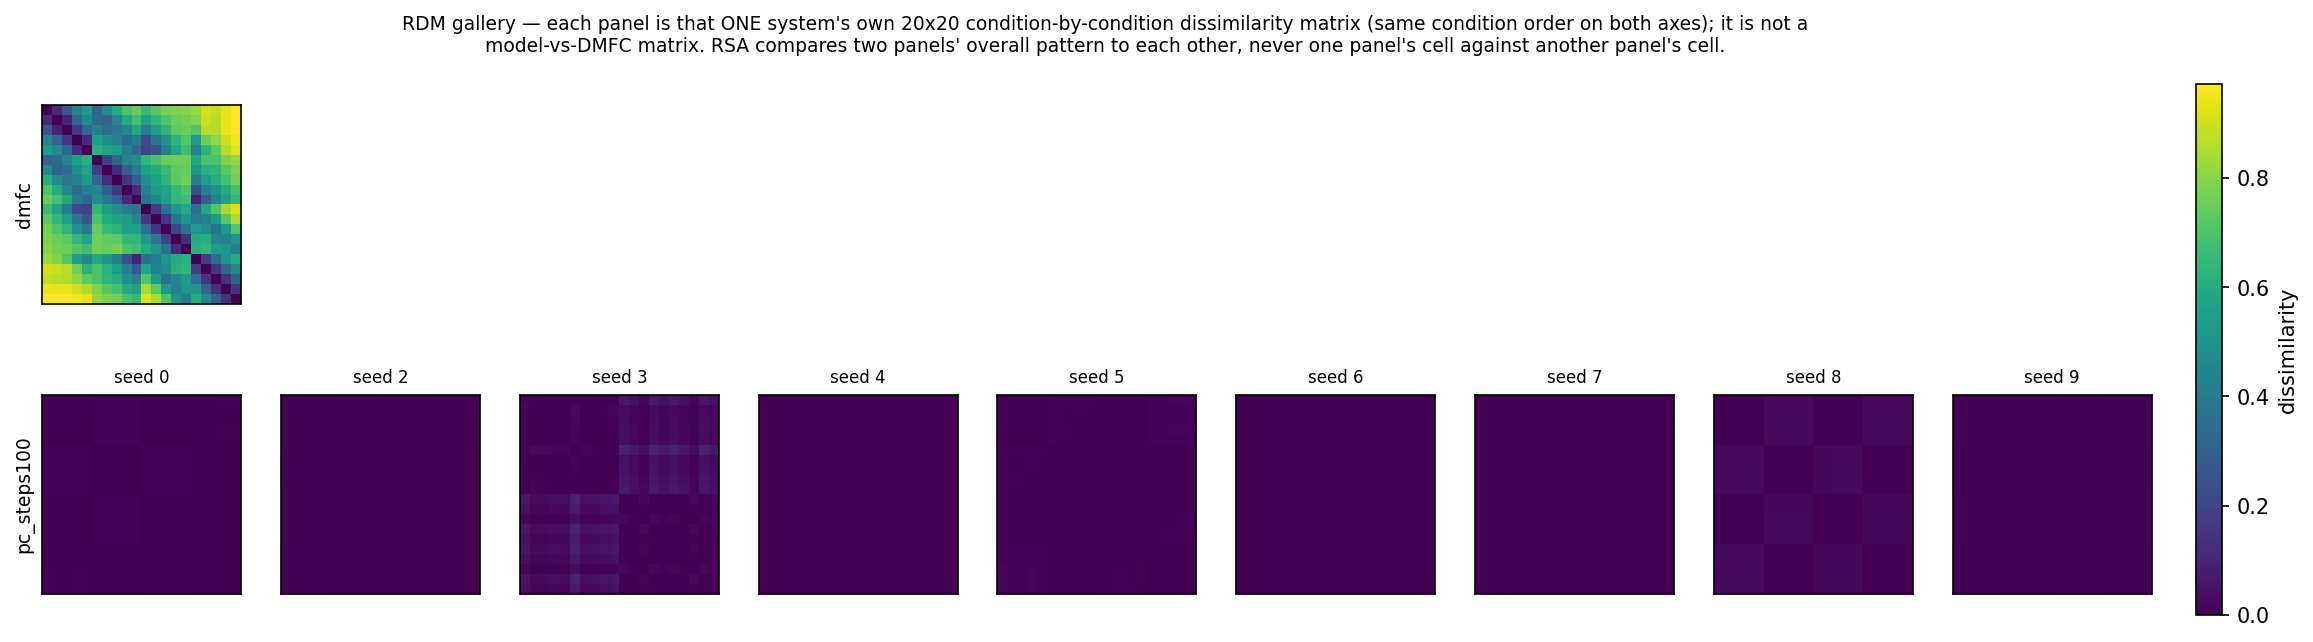

In [6]:
display(Image(filename=RSA_DIR / "pc_steps100_vs_dmfc" / "figures" / "rdm_gallery_pc.png"))

## Classical MDS: condition structure in representational space

MDS takes an RDM and finds a 2D layout of the 20 conditions where distances on the
page approximate the RDM's dissimilarities as closely as possible — a direct picture
of the representational geometry, rather than reading numbers out of a matrix. Points
are colored by **prior** (blue=short, orange=long) and shaped by **effector**
(circle=eye, triangle=hand).

**What a "good" panel looks like:** blue and orange points forming separate clusters
(the system distinguishes prior), and within each cluster, circles and triangles
further separated (the system distinguishes effector) — matching DMFC's own panel's
pattern of separation.

**Why panels are drawn separately, not overlaid:** each panel is its own independently-
fit embedding. Two MDS solutions computed separately can come out rotated or mirrored
relative to each other even when the underlying geometry is genuinely similar — there
is no canonical orientation. So compare the *pattern* (does color/shape separate
cleanly, and how much space does the whole layout occupy) across panels, not the
absolute coordinates or orientation.

### BPTT (10/10 seeds)

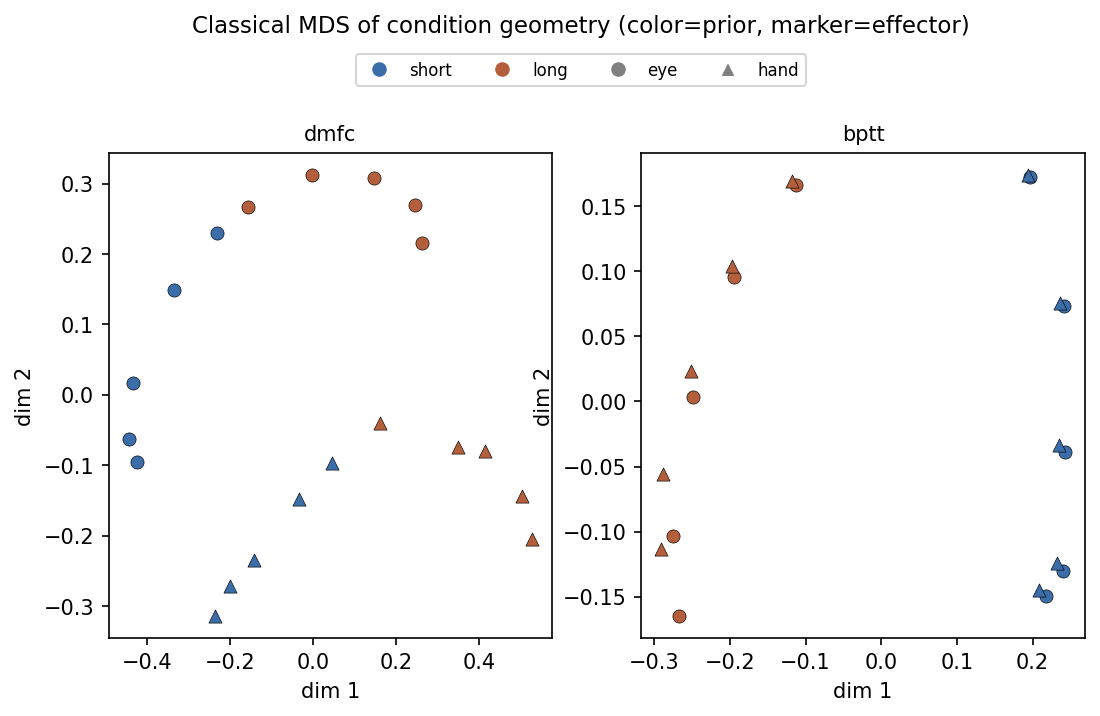

In [7]:
display(Image(filename=RSA_DIR / "bptt_vs_dmfc" / "figures" / "mds_bptt.png"))

### RFLO (10/10 seeds)

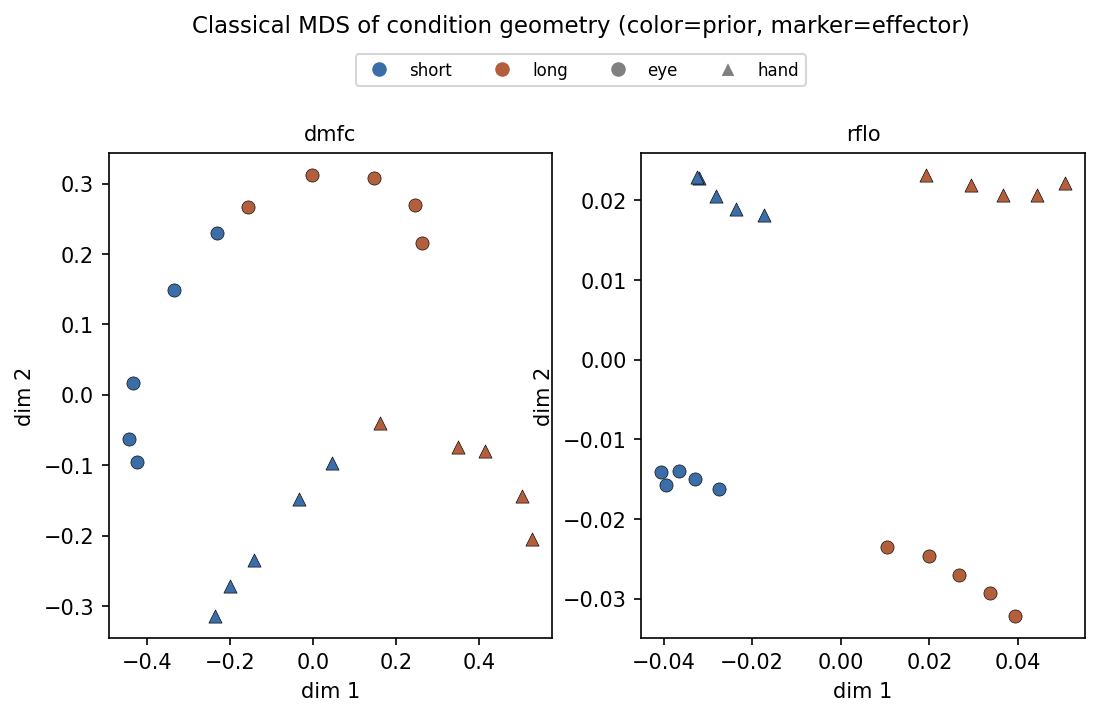

In [8]:
display(Image(filename=RSA_DIR / "rflo_vs_dmfc" / "figures" / "mds_rflo.png"))

### PC, pc_inference_steps=20 (seeds 1,5,7,9 only)

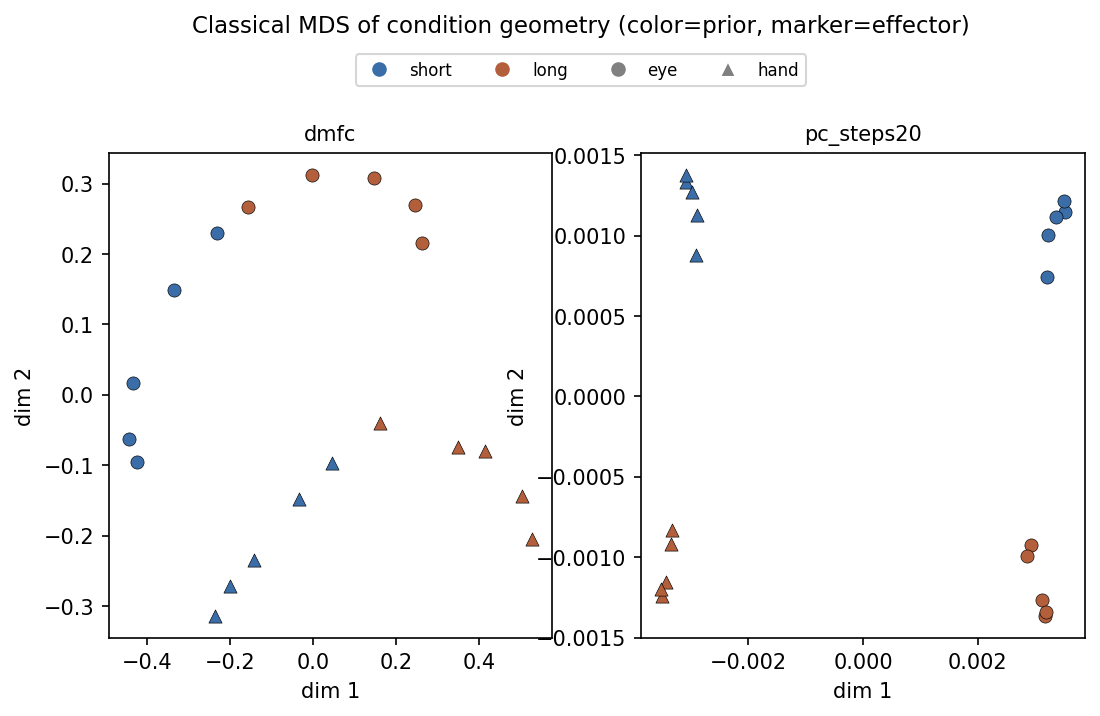

In [9]:
display(Image(filename=RSA_DIR / "pc_steps20_vs_dmfc" / "figures" / "mds_pc.png"))

### PC, pc_inference_steps=100 (all but seed 1)

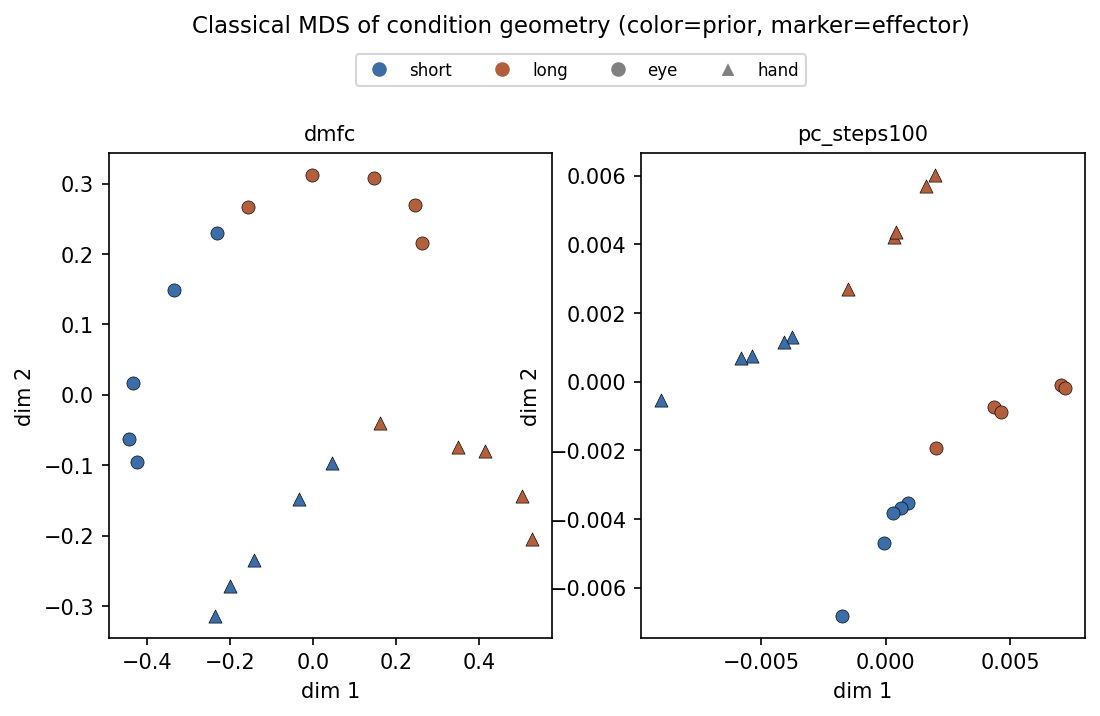

In [10]:
display(Image(filename=RSA_DIR / "pc_steps100_vs_dmfc" / "figures" / "mds_pc.png"))

## Time-resolved RSA: distance to DMFC across the trial

Instead of one RDM per system built from the whole trial at once, this builds one RDM
**per time bin** (25 bins spanning the 3000ms trial) and computes the model-vs-DMFC
distance at each bin separately — the RSA analogue of asking "at this specific moment
in the trial, how similar is the model's condition geometry to the brain's?" rather
than a single trial-averaged number.

- **x-axis**: time in ms since trial start (Ready onset is at ~100ms; Set and Go land
  at different times per condition, so no single vertical line marks them for every
  condition at once).
- **y-axis**: RSA distance to DMFC at that instant — lower is more similar. The shaded
  band per line is the +/- 1 seed-standard-deviation spread.
  Combines all four arms onto one axis; the light gray band is the neural noise
  ceiling (the same one used in `results_summary.ipynb`'s scalar comparison) — no arm
  reaching into that band would mean it matched DMFC's own split-half consistency at
  that moment.
- Each arm's own single-arm version (and each individual seed's own curve) is also
  saved: the combined figure below is `results/rsa/temporal_all_arms.png`; a single
  seed's own curve lives at
  `results/figures/<arm>/seed_XXXX/<rule>_rsa_temporal.png`.

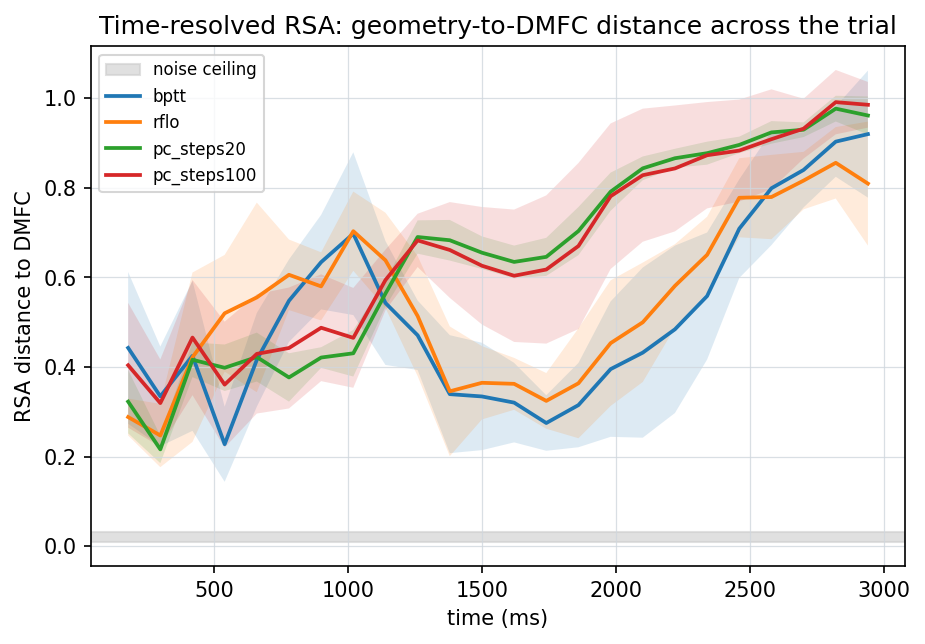

In [11]:
display(Image(filename=RSA_DIR / "temporal_all_arms.png"))

## Findings

- **RDM geometry and MDS** are broadly consistent across seeds within an arm (the RDM
  gallery rows look visually similar seed-to-seed), and the MDS panels separate
  conditions along prior/effector to varying degrees per arm/DMFC — read this next to
  `results_summary.ipynb`'s scalar RSA distance, not as a replacement for it. Notably,
  DMFC's own MDS embedding shows clean prior separation at a scale of roughly +/-0.4;
  PC's embeddings (both step variants) sit at a scale roughly 1000x smaller
  (+/-0.005ish) with far less visible separation — a striking match to the parked
  fixed-point-collapse finding (PC's `forward()` rollout provably lands on 4
  `ts`-independent fixed points), worth carrying into any write-up of that finding.
- **Time-resolved RSA** shows a real pattern, not a flat line: distance to DMFC rises
  across the trial for every arm (the early, pre-stimulus baseline is the most
  DMFC-like period, expected since there is little condition structure to get wrong
  yet). `bptt` and `rflo` both show a mid-trial dip (roughly the Set-to-Go window)
  that neither PC variant shows to the same degree — PC's curve stays closer to its
  peak through that window. Consistent with (not independent confirmation of) the same
  collapse finding: a model whose dynamics don't depend on `ts` has less capacity to
  track DMFC's own time-varying, `ts`-dependent geometry specifically where that
  dependence matters most.
- No arm gets close to the neural noise ceiling at any point in the trial.
- This is a single ingestion pass — per `AGENTS.md` ("seeds are the unit of
  evidence"), the per-seed RDM gallery and per-seed curves, not this paragraph, are
  the actual evidence.